In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

In [5]:

## Step 1: Load and Preprocess Data
# Define transformations for images
transform = transforms.Compose([
    transforms.ToTensor(),          # Convert images to tensors
    transforms.Normalize((0.5,), (0.5,))  # Normalize images
])


In [6]:
# Load Fashion-MNIST dataset
train_dataset = torchvision.datasets.FashionMNIST(root="./data", train=True, transform=transform, download=True)
test_dataset = torchvision.datasets.FashionMNIST(root="./data", train=False, transform=transform, download=True)



100%|██████████| 26.4M/26.4M [00:01<00:00, 15.3MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 273kB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 5.04MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 8.66MB/s]


In [7]:
# Get the shape of the first image in the training dataset
image, label = train_dataset[0]
print(image.shape)
print(len(train_dataset))

torch.Size([1, 28, 28])
60000


In [8]:
# Get the shape of the first image in the test dataset
image, label = test_dataset[0]
print(image.shape)
print(len(test_dataset))


torch.Size([1, 28, 28])
10000


In [9]:

# Create DataLoader for batch processing
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)


In [21]:
class CNNClassifier(nn.Module):
    def __init__(self):
        super(CNNClassifier, self).__init__()

        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)

        self.fc1 = nn.Linear(64 * 7 * 7, 128)
        self.fc2 = nn.Linear(128, 10)

        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.relu(self.conv1(x))
        x = self.pool(x)

        x = self.relu(self.conv2(x))
        x = self.pool(x)

        x = x.view(x.size(0), -1)

        x = self.relu(self.fc1(x))
        x = self.fc2(x)

        return x


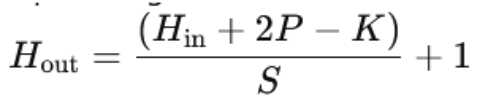

In [15]:
pip install torchinfo


In [22]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = CNNClassifier().to(device)

print("Name: SUBHASH V")
print("Register Number: 212224240163")

summary(model, input_size=(1, 1, 28, 28), device=device)


Name: SUBHASH V
Register Number: 212224240163


Layer (type:depth-idx)                   Output Shape              Param #
CNNClassifier                            [1, 10]                   --
├─Conv2d: 1-1                            [1, 32, 28, 28]           320
├─ReLU: 1-2                              [1, 32, 28, 28]           --
├─MaxPool2d: 1-3                         [1, 32, 14, 14]           --
├─Conv2d: 1-4                            [1, 64, 14, 14]           18,496
├─ReLU: 1-5                              [1, 64, 14, 14]           --
├─MaxPool2d: 1-6                         [1, 64, 7, 7]             --
├─Linear: 1-7                            [1, 128]                  401,536
├─ReLU: 1-8                              [1, 128]                  --
├─Linear: 1-9                            [1, 10]                   1,290
Total params: 421,642
Trainable params: 421,642
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 4.28
Input size (MB): 0.00
Forward/backward pass size (MB): 0.30
Params size (MB): 1.69
Estimated Total S

In [23]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)


In [32]:
def train_model(model, train_loader, num_epochs=3):
    model.train()

    for epoch in range(num_epochs):
        running_loss = 0.0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        print("Name: SUBHASH V")
        print("Register Number: 212224240163")
        print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {running_loss/len(train_loader):.4f}")


In [33]:
train_model(model, train_loader)


Name: SUBHASH V
Register Number: 212224240163
Epoch [1/3], Loss: 0.1775
Name: SUBHASH V
Register Number: 212224240163
Epoch [2/3], Loss: 0.1515
Name: SUBHASH V
Register Number: 212224240163
Epoch [3/3], Loss: 0.1264


In [30]:
def test_model(model, test_loader):
    model.eval()
    correct = 0
    total = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    accuracy = correct / total

    print("Name: SUBHASH V")
    print("Register Number: 212224240163")
    print(f"Test Accuracy: {accuracy:.4f}")

    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(8, 6))
    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Blues",
        xticklabels=test_dataset.classes,
        yticklabels=test_dataset.classes
    )
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title("Confusion Matrix")
    plt.show()

    print("Classification Report:")
    print(classification_report(all_labels, all_preds, target_names=test_dataset.classes))


Name: SUBHASH V
Register Number: 212224240163
Test Accuracy: 0.9097


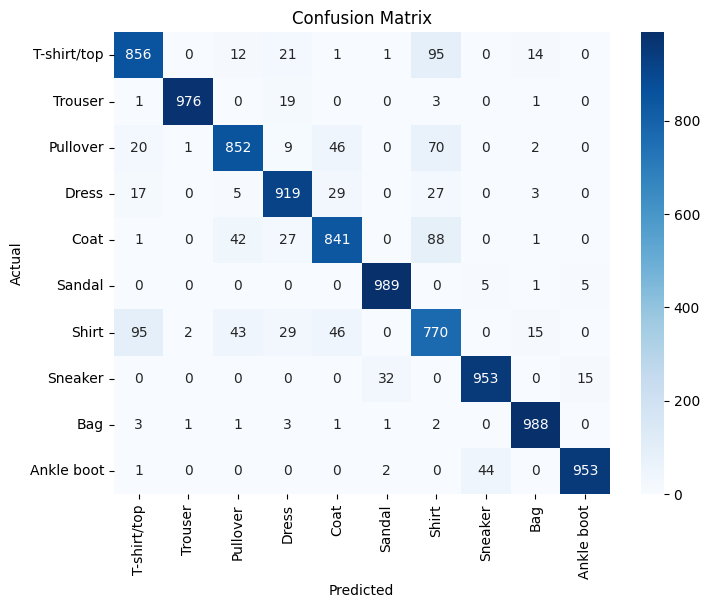

Classification Report:
              precision    recall  f1-score   support

 T-shirt/top       0.86      0.86      0.86      1000
     Trouser       1.00      0.98      0.99      1000
    Pullover       0.89      0.85      0.87      1000
       Dress       0.89      0.92      0.91      1000
        Coat       0.87      0.84      0.86      1000
      Sandal       0.96      0.99      0.98      1000
       Shirt       0.73      0.77      0.75      1000
     Sneaker       0.95      0.95      0.95      1000
         Bag       0.96      0.99      0.98      1000
  Ankle boot       0.98      0.95      0.97      1000

    accuracy                           0.91     10000
   macro avg       0.91      0.91      0.91     10000
weighted avg       0.91      0.91      0.91     10000



In [31]:
test_model(model, test_loader)


In [28]:
def predict_image(model, image_index, dataset):
    model.eval()

    image, label = dataset[image_index]
    image = image.to(device)

    with torch.no_grad():
        output = model(image.unsqueeze(0))
        _, predicted = torch.max(output, 1)

    class_names = dataset.classes

    print("Name: SUBHASH V")
    print("Register Number: 212224240163")

    plt.imshow(image.cpu().squeeze(), cmap="gray")
    plt.title(f"Actual: {class_names[label]} | Predicted: {class_names[predicted.item()]}")
    plt.axis("off")
    plt.show()

    print(f"Actual: {class_names[label]}")
    print(f"Predicted: {class_names[predicted.item()]}")


Name: SUBHASH V
Register Number: 212224240163


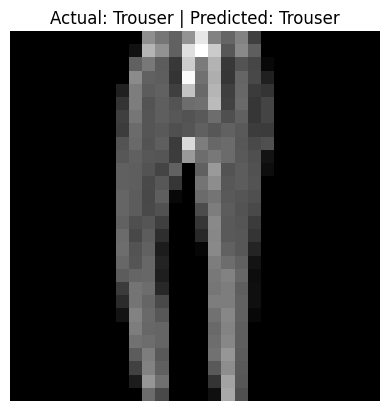

Actual: Trouser
Predicted: Trouser


In [29]:
predict_image(model, image_index=80, dataset=test_dataset)
